In [1]:
from FIT_python.plot_style import apply_style
apply_style()



📥 Schritt 1: Datenimport & Cleaning
[REPORT] cleaned Aj_Someringii: shape=(370, 141)
[REPORT] cleaned Amur_Tiger: shape=(605, 133)
[REPORT] cleaned Bengal_tiger: shape=(586, 133)
[REPORT] cleaned cheetah: shape=(781, 141)
[REPORT] cleaned Eurasian_Otter: shape=(628, 214)
[REPORT] cleaned Giant_Panda: shape=(523, 129)
[REPORT] cleaned Jubatus: shape=(566, 141)
[REPORT] cleaned Lowlandtapir: shape=(426, 126)
[REPORT] cleaned Mountain_Lion: shape=(535, 138)
[REPORT] cleaned White_Rhino: shape=(1273, 117)
[SUCCESS] clean_all completed.

✂️ Schritt 2: Splitting & Fold-Zuordnung
✅ Fold method used: stratified_group
Fold
0     98
1    112
2     90

📊 aj_someringii – train – 300 Zeilen | 20 Individuen | 43 Trails
sex
m    153
f    147

📊 aj_someringii – test – 70 Zeilen | 5 Individuen | 10 Trails
sex
f    42
m    28

📊 aj_someringii – inference – 0 Zeilen | 0 Individuen | 0 Trails
Series([], )

✅ aj_someringii gespeichert (csv & parquet)
✅ Fold method used: stratified_group
Fold
0    169
1   

C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\data_split_and_summary\split_utils.py:213: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_df["Fold"] = fold_ids
C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\data_split_and_summary\split_utils.py:213: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df["Fold"] = fold_ids



📊 eurasian_otter – train – 395 Zeilen | 27 Individuen | 54 Trails
sex
f    220
m    175

📊 eurasian_otter – test – 152 Zeilen | 14 Individuen | 19 Trails
sex
f    86
m    66

📊 eurasian_otter – inference – 81 Zeilen | 1 Individuen | 8 Trails
sex
unknown    81

✅ eurasian_otter gespeichert (csv & parquet)
✅ Fold method used: stratified_group
Fold
0     88
1    144
2    172

📊 giant_panda – train – 404 Zeilen | 33 Individuen | 61 Trails
sex
f    238
m    166

📊 giant_panda – test – 119 Zeilen | 9 Individuen | 16 Trails
sex
f    63
m    56

📊 giant_panda – inference – 0 Zeilen | 0 Individuen | 0 Trails
Series([], )

✅ giant_panda gespeichert (csv & parquet)
✅ Fold method used: stratified_group
Fold
0    153
1    147
2    147

📊 jubatus – train – 447 Zeilen | 32 Individuen | 64 Trails
sex
f    258
m    189

📊 jubatus – test – 119 Zeilen | 8 Individuen | 17 Trails
sex
f    70
m    49

📊 jubatus – inference – 0 Zeilen | 0 Individuen | 0 Trails
Series([], )

✅ jubatus gespeichert (csv & parq

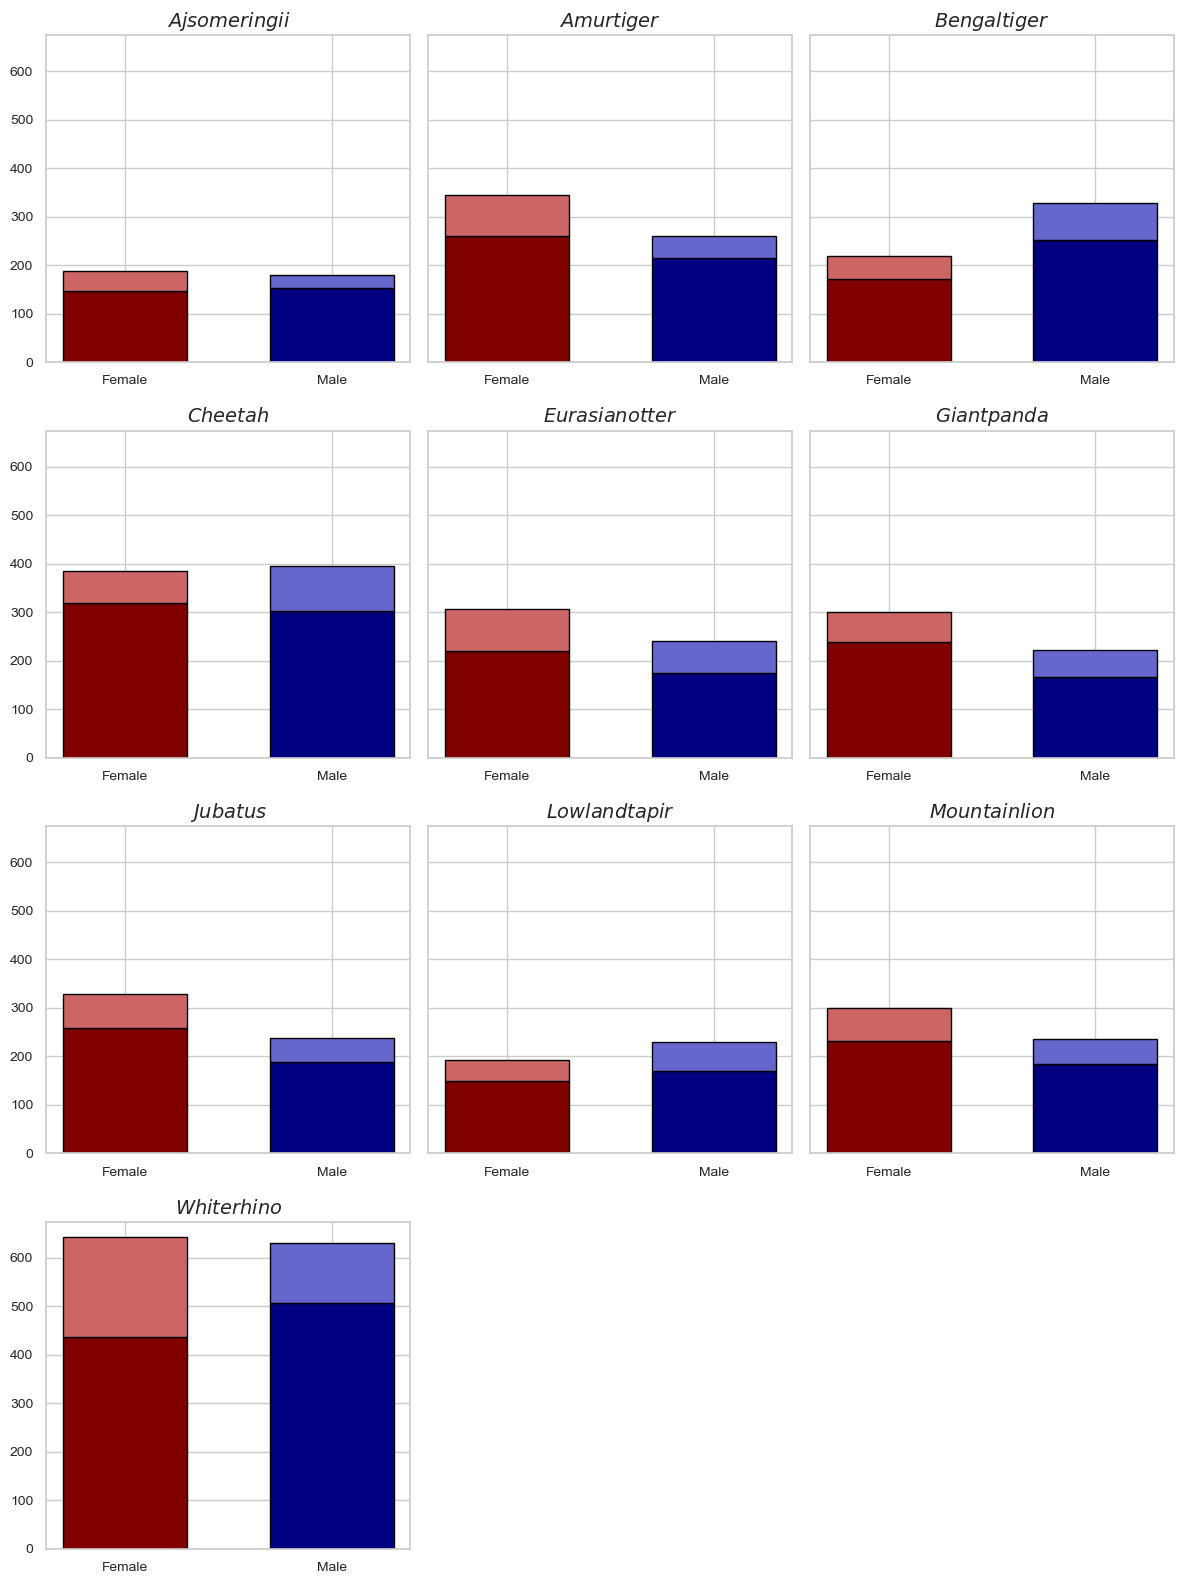

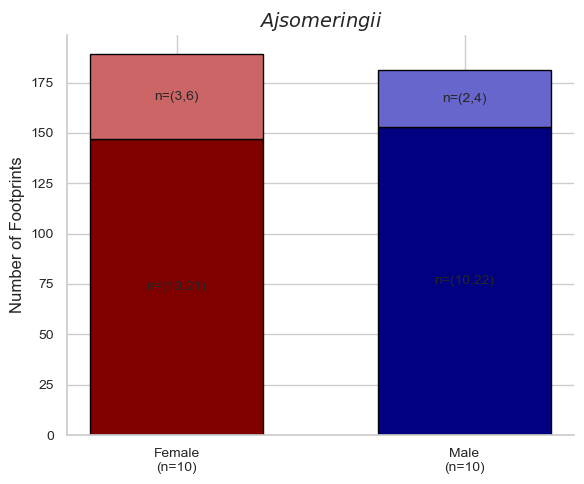

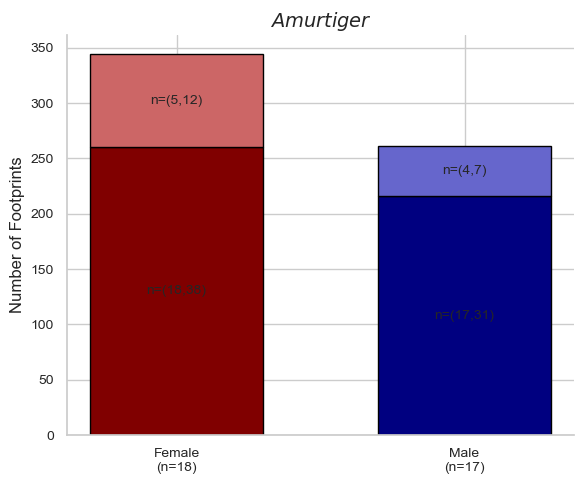

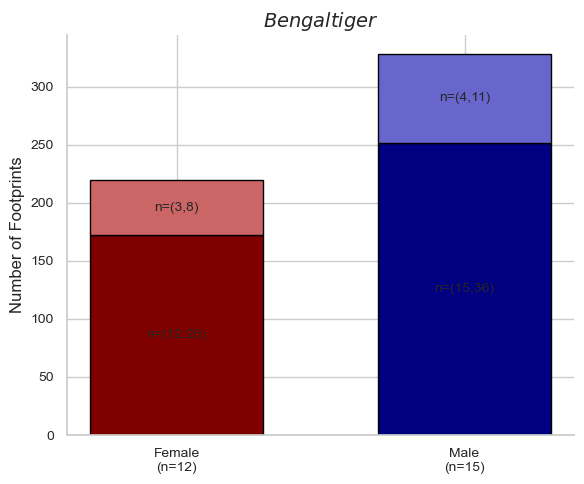

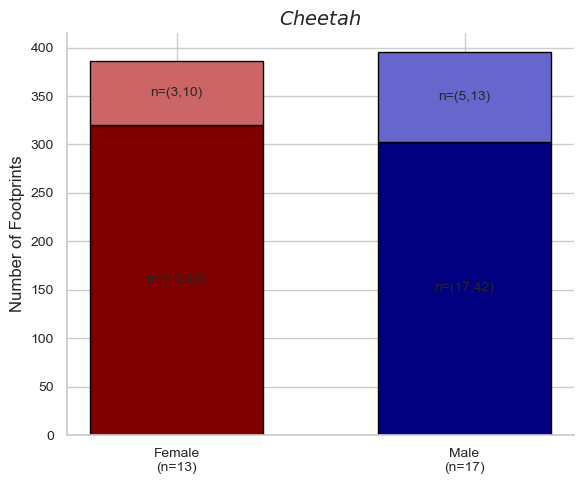

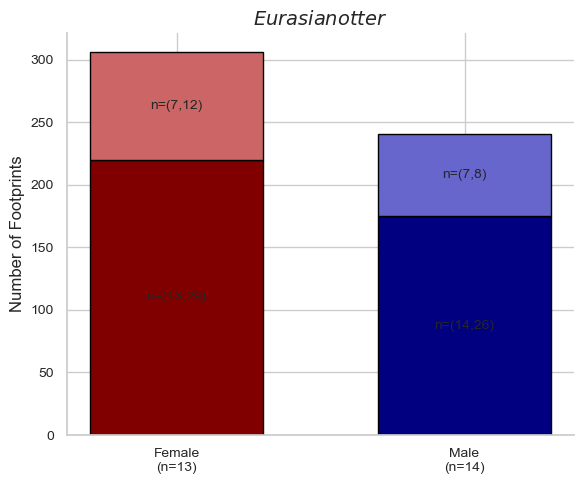

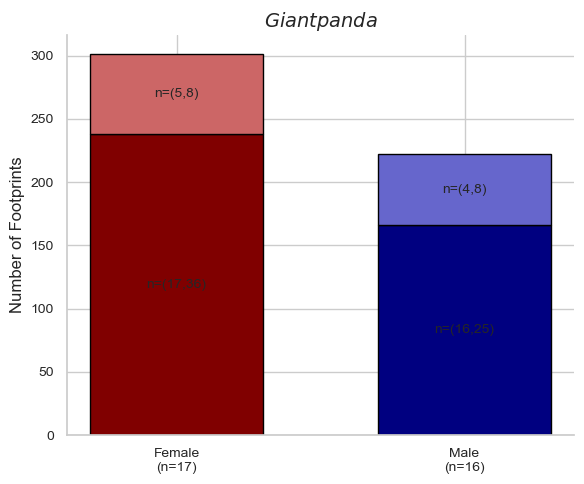

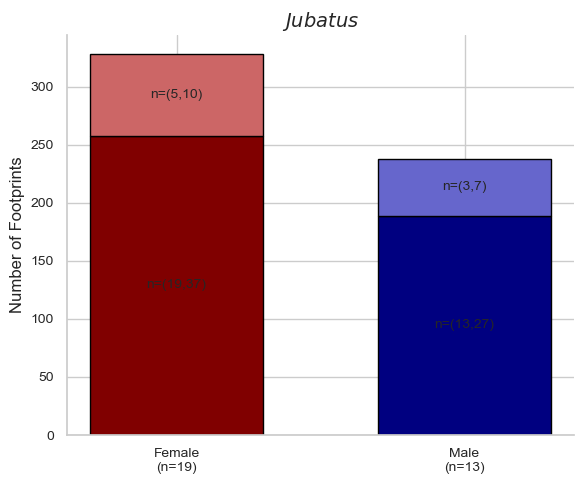

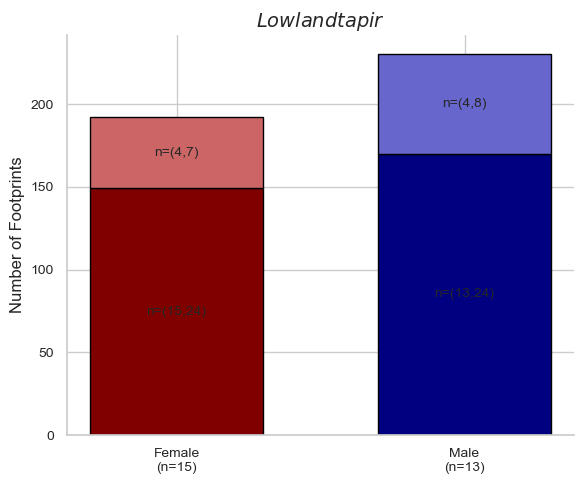

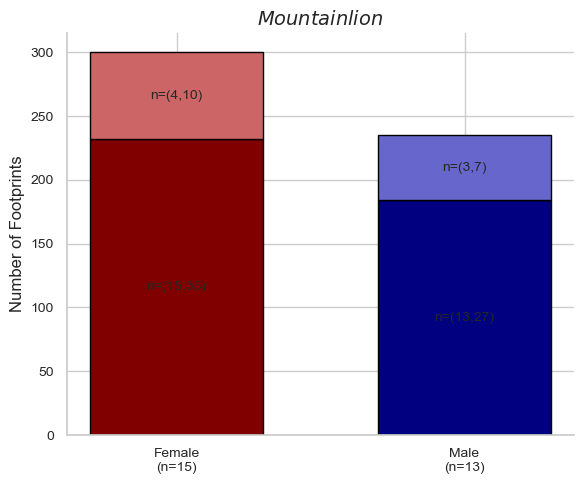

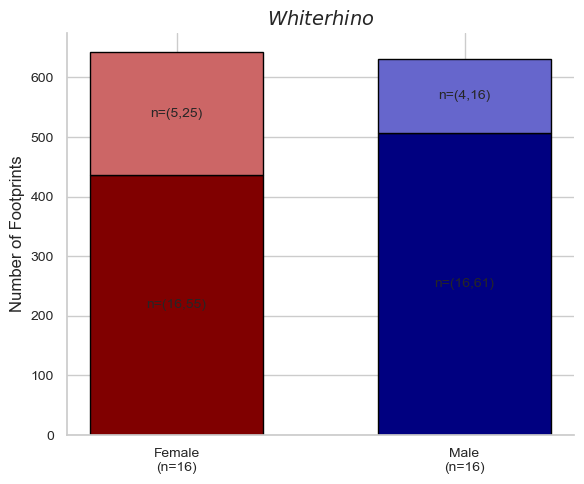

In [2]:
# %% [code]
from pathlib import Path
import pandas as pd
import numpy as np
import ast
from tqdm.auto import tqdm
from joblib import Parallel, delayed
from sklearn.model_selection import ParameterSampler

from FIT_python.pipeline_sex.pipeline_wrapper_sex import PipelineWrapper
from FIT_python.config import RESULTS_DATA_DIR

# 1) Prepare (Clean → Split → Summary)
prep = PipelineWrapper(
    model_keys=["log_reg"],  # Dummy
    impute_method=None,
    outlier_method=None,
    scaler_method=None,
    reduce_pre_method=None,
    reduce_post_method=None,
    fs_method=None,
    fs_k=None,
)
prep.prepare()



In [3]:
import shutil
from FIT_python.pipeline_sex.pipeline_wrapper_sex import _cache_dir

# Cache-Verzeichnis komplett entfernen
shutil.rmtree(_cache_dir)
print(f"Cache gelöscht: {_cache_dir}")


Cache gelöscht: C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\results\data\pipeline_cache


In [5]:
# %% [code] RandomizedGridSearchCV mit Standard-Metriken & Custom-Auswertung (aggregiert)
from pathlib import Path
import pandas as pd
import numpy as np
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from tqdm.auto import tqdm
from tqdm_joblib import tqdm_joblib
import joblib
from functools import reduce
import operator

from sklearn.metrics import accuracy_score, balanced_accuracy_score
from FIT_python.pipeline_sex.transform_wrapper                import NumericTransformer
from FIT_python.pipeline_sex.feature_selection_wrapper        import FeatureSelectionTransformer
from FIT_python.pipeline_sex.outlier_wrapper                  import OutlierCleanerTransformer
from FIT_python.pipeline_sex.feature_scaler_wrapper           import FeatureScalerTransformer
from FIT_python.pipeline_sex.dimensionality_reduction_wrapper import DimensionalityReducerTransformer
from FIT_python.pipeline_sex.models                           import MODELS
from FIT_python.pipeline_sex.grouped_metrics                  import individual_accuracies, individual_majority_stats
from FIT_python.config                                        import SPLITS_DIR, RESULTS_DATA_DIR

import warnings
from sklearn.exceptions import ConvergenceWarning

# Warnings nur einmal
warnings.filterwarnings("once", category=ConvergenceWarning, message="Objective did not converge.*")
warnings.filterwarnings("once", category=UserWarning,       message="X does not have valid feature names.*")

# 1) Modell‐Keys
model_keys = [
    "logreg_l2","logreg_l1",
    "rf_small","rf_med","rf_large",
    "knn_3","knn_5","knn_7",
    "svm_linear","svm_rbf",
    "xgb_std","xgb_hist",
    "lgbm_std","lgbm_md10",
    "lda",
]

# 2) Param‐Räume (inkl. PCA/UMAP‐ & Outlier‐Hyperparams)
param_distributions = {
    # Feature Selection (inkl. RF)
    "select__method":          [None, "forward", "lasso", "variance", "random_forest"],
    "select__k":               [1,2,3,4,5,6,10, 20, 50,100],

    # --- nachher ---
    "outlier__method":         [None, "clip"],
    "outlier__lower_quantile": [0.01, 0.05],
    "outlier__upper_quantile": [0.90, 0.95],

    # Scaling
    "scale__method":           [None, "standard", "robust", "minmax"],

    # DimRed Pre
    "reduce_pre__method":        [None, "pca", "umap"],
    "reduce_pre__n_components":  [2, 10],
    "reduce_pre__n_neighbors":   [5, 10, 15, 30, 50],   # ← mehr Nachbarn
    "reduce_pre__min_dist":      [0.1, 0.5],
    "reduce_pre__whiten":        [False, True],

    # DimRed Post
    "reduce_post__method":       [None, "pca", "umap"],
    "reduce_post__n_components": [2, 10],
    "reduce_post__n_neighbors":  [5, 10, 15, 30, 50],   # ← mehr Nachbarn
    "reduce_post__min_dist":     [0.1, 0.5],
    "reduce_post__whiten":       [False, True],

    # Classifier
    "clf": [MODELS[k] for k in model_keys],
}

# 3) Wie groß ist der Suchraum?
lengths = {k: len(v) for k,v in param_distributions.items()}
total_combinations = reduce(operator.mul, lengths.values(), 1)

print("Anzahl der Werte pro Parameter:")
for k, l in lengths.items():
    print(f"  {k:25s}: {l}")
print(f"\n→ Gesamtzahl aller Hyper‐Kombinationen: {total_combinations:,}")


# 3) Ergebnis-Ordner
base_dir = Path(RESULTS_DATA_DIR) / "eurasian_otter_random_search_standard_metrics"
base_dir.mkdir(parents=True, exist_ok=True)

# Unterordner für Best-Modelle je Metrik
metrics = [
    "maj_test_pct",
    "balanced_test_acc",      # <-- hier
    "accuracy_test",
    "mean_test_neg_log_loss"
]
for m in metrics:
    (base_dir / f"best_{m}").mkdir(exist_ok=True)

# 4) Scoring-Dict
scoring = {
    "accuracy":          "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "neg_log_loss":      "neg_log_loss",
}

pipeline_order = [
    "outlier__method", "outlier__lower_quantile", "outlier__upper_quantile",
    "scale__method", "select__method", "select__k",
    "reduce_pre__method", "reduce_pre__n_components", "reduce_pre__n_neighbors", "reduce_pre__min_dist", "reduce_pre__whiten",
    "reduce_post__method", "reduce_post__n_components", "reduce_post__n_neighbors", "reduce_post__min_dist", "reduce_post__whiten",
    "clf"
]


# 5) Sammel-Listen
raw_records  = []
best_records = []

# 6) Loop über Spezies
species_dir = Path(SPLITS_DIR)/"eurasian_otter"
species = "eurasian_otter"
print(f"\n🔄 Processing species: {species}")

# 6.1) Train/Test laden & Fold entfernen
df_train = (pd.read_parquet(species_dir / "train.parquet")
                .query("sex in ['f','m']")
                .drop(columns=["Fold"], errors="ignore"))
df_test  = (pd.read_parquet(species_dir / "test.parquet")
                .query("sex in ['f','m']")
                .drop(columns=["Fold"], errors="ignore"))

# 🔍 Feature-Spalten abhängig von Spezies auswählen
if species == "eurasian_otter":
    feature_cols = [
        c for c in df_train.columns 
        if c.startswith(("dist", "ang", "t")) and pd.api.types.is_numeric_dtype(df_train[c])
    ]
else:
    feature_cols = [
        c for c in df_train.columns[5:] 
        if pd.api.types.is_numeric_dtype(df_train[c])
    ]
print(f"  → {len(feature_cols)} numerische Features")

# 6.2) Features, Ziel & IDs
X_tr, y_tr, ids_tr = (
    df_train[feature_cols],
    df_train["sex"].map({"f":0,"m":1}).values,
    df_train["individual_id"].values
)
X_te, y_te, ids_te = (
    df_test[feature_cols],
    df_test["sex"].map({"f":0,"m":1}).values,
    df_test["individual_id"].values
)

# 6.3) Pipeline
steps = [
    ("transform",   NumericTransformer()),                                   # 1) Grund-Transformationen
    ("outlier",     OutlierCleanerTransformer(method="clip")),               # 2) Ausreißer entfernen
    ("scale",       FeatureScalerTransformer(method="standard")),            # 3) Skalierung
    ("select",      FeatureSelectionTransformer(method="forward", k=1)),     # 4) Feature-Selektion
    ("reduce_pre",  DimensionalityReducerTransformer(method=None, n_components=1)),  # 5) erste Dimensionstahlung
    ("reduce_post", DimensionalityReducerTransformer(method=None, n_components=1)),  # 6) zweite Dimensionstahlung (z. B. Visualisierung)
    ("clf",         MODELS["rf_small"]),                                     # 7) Klassifikator
]
pipe = Pipeline(steps)

# 6.4) RandomizedSearchCV
search = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_distributions,
    n_iter=30,      # kleiner Testdurchgang
    scoring=scoring,
    refit=False,
    cv=2,
    n_jobs=-1,
    random_state=42,
    verbose=1,
)

# 6.5) Fit mit tqdm (dynamisch berechnete Gesamt-Anzahl an Fits)
n_iter = search.n_iter
# wenn cv ein Integer ist, nutzen wir es direkt, sonst versuchen wir n_splits zu lesen
folds  = search.cv if isinstance(search.cv, int) else getattr(search.cv, "n_splits", len(list(search.cv)))
total_fits = n_iter * folds

with tqdm_joblib(tqdm(desc=f"{species} RS-CV", total=total_fits, leave=False)):
    search.fit(X_tr, y_tr)

# 6.6) CV-Ergebnisse & Custom-Metriken sammeln
cv_res = search.cv_results_
for i, params in enumerate(cv_res["params"]):
    record = {
        "species":                     species,
        "mean_test_accuracy":          cv_res["mean_test_accuracy"][i],
        "mean_test_balanced_accuracy": cv_res["mean_test_balanced_accuracy"][i],
        "mean_test_neg_log_loss":      cv_res["mean_test_neg_log_loss"][i],
        **params
    }
    # kompletter Re-Fit für Custom-Metriken
    mdl = clone(pipe).set_params(**params).fit(X_tr, y_tr)
    y_tr_pred = mdl.predict(X_tr)
    y_te_pred = mdl.predict(X_te)
    y_all_true = np.concatenate([y_tr, y_te])
    y_all_pred = np.concatenate([y_tr_pred, y_te_pred])
    ids_all     = np.concatenate([ids_tr, ids_te])

    fem_tr, mal_tr, bal_tr    = individual_accuracies(y_tr, y_tr_pred, ids_tr)
    fem_te, mal_te, bal_te    = individual_accuracies(y_te, y_te_pred, ids_te)
    ct_tr, wr_tr, pct_tr      = individual_majority_stats(y_tr, y_tr_pred, ids_tr)
    ct_te, wr_te, pct_te      = individual_majority_stats(y_te, y_te_pred, ids_te)
    fem_all, mal_all, bal_all = individual_accuracies(y_all_true, y_all_pred, ids_all)
    ct_all, wr_all, pct_all   = individual_majority_stats(y_all_true, y_all_pred, ids_all)
            # Accuracy & Balanced Accuracy
    acc_tr  = accuracy_score(y_tr,  y_tr_pred)
    bal_tr  = balanced_accuracy_score(y_tr,  y_tr_pred)
    acc_te  = accuracy_score(y_te,  y_te_pred)
    bal_te  = balanced_accuracy_score(y_te,  y_te_pred)

    # Neu: Full-Dataset Accuracy & Balanced Accuracy
    acc_all = accuracy_score(y_all_true, y_all_pred)
    bal_all = balanced_accuracy_score(y_all_true, y_all_pred)

    

    record.update({
        "female_train_acc":   fem_tr, "male_train_acc":   mal_tr, "balanced_train_acc": bal_tr, "accuracy_train":          acc_tr,
        "female_test_acc":    fem_te, "male_test_acc":    mal_te, "balanced_test_acc":  bal_te, "accuracy_test":          acc_te,
        "female_full_acc":    fem_all,"male_full_acc":    mal_all,"balanced_full_acc":  bal_all,"accuracy_full":          acc_all,
        "maj_train_count":    ct_tr, "maj_train_wrong":  wr_tr, "maj_train_pct":      pct_tr,
        "maj_test_count":     ct_te, "maj_test_wrong":   wr_te, "maj_test_pct":       pct_te,
        "maj_full_count":     ct_all,"maj_full_wrong":   wr_all,"maj_full_pct":       pct_all,
    })
    
    # 1) pipeline_id bauen
    pid_parts = []
    for key in pipeline_order:
        val = params.get(key)
        pid_parts.append(f"{key}={val if val is not None else 'None'}")
    record["pipeline_id"] = ";".join(pid_parts)

    # 2) Alle NaNs in "None" umwandeln
    for k, v in record.items():
        if pd.isna(v):
            record[k] = "None"
    raw_records.append(record)

# 6.7) Beste Modelle je Metrik speichern UND Joblib dump
df_eval = pd.DataFrame([r for r in raw_records if r["species"] == species])
for metric in metrics:
    # Index und Parameter des besten Runs finden
    best_idx    = df_eval[metric].idxmax()
    best_params = cv_res["params"][best_idx]
    # Erstelle das Record-Dict für best_records
    best_record = df_eval.loc[best_idx].to_dict()
    best_record["best_metric"] = metric

    # Finales Modell trainieren und speichern
    best_pipe = clone(pipe).set_params(**best_params).fit(X_tr, y_tr)
    out_path = base_dir / f"best_{metric}" / f"{species}.joblib"
    joblib.dump(best_pipe, out_path)
    print(f"✅ Modell für Spezies '{species}', Kriterium '{metric}' gespeichert unter:\n   {out_path}")

    # **Ganz wichtig**: best_record in best_records einfuegen
    best_records.append(best_record)

# → CSVs direkt aktualisieren (innerhalb des Species-Loops)
all_csv  = base_dir / "all_results.csv"
best_csv = base_dir / "best_models.csv"
# DataFrames bauen und alle NaNs in "None" umwandeln
df_all  = pd.DataFrame(raw_records).fillna("None")
df_best = pd.DataFrame(best_records).fillna("None")

# CSVs speichern
df_all.to_csv(all_csv,  index=False)
df_best.to_csv(best_csv, index=False)



Anzahl der Werte pro Parameter:
  select__method           : 5
  select__k                : 10
  outlier__method          : 2
  outlier__lower_quantile  : 2
  outlier__upper_quantile  : 2
  scale__method            : 4
  reduce_pre__method       : 3
  reduce_pre__n_components : 2
  reduce_pre__n_neighbors  : 5
  reduce_pre__min_dist     : 2
  reduce_pre__whiten       : 2
  reduce_post__method      : 3
  reduce_post__n_components: 2
  reduce_post__n_neighbors : 5
  reduce_post__min_dist    : 2
  reduce_post__whiten      : 2
  clf                      : 15

→ Gesamtzahl aller Hyper‐Kombinationen: 345,600,000

🔄 Processing species: eurasian_otter
  → 205 numerische Features


eurasian_otter RS-CV:   0%|          | 0/60 [00:00<?, ?it/s]

  0%|          | 0/60 [00:00<?, ?it/s]

Fitting 2 folds for each of 30 candidates, totalling 60 fits


c:\Users\Frede\anaconda3\envs\FIT_python_conda_env\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.218e-02, tolerance: 7.490e-03
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\Frede\anaconda3\envs\FIT_python_conda_env\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.561e-02, tolerance: 7.490e-03
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\Frede\anaconda3\envs\FIT_python_conda_env\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale

✅ Modell für Spezies 'eurasian_otter', Kriterium 'maj_test_pct' gespeichert unter:
   C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\results\data\eurasian_otter_random_search_standard_metrics\best_maj_test_pct\eurasian_otter.joblib
✅ Modell für Spezies 'eurasian_otter', Kriterium 'balanced_test_acc' gespeichert unter:
   C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\results\data\eurasian_otter_random_search_standard_metrics\best_balanced_test_acc\eurasian_otter.joblib
✅ Modell für Spezies 'eurasian_otter', Kriterium 'accuracy_test' gespeichert unter:
   C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\results\data\eurasian_otter_random_search_standard_metrics\best_accuracy_test\eurasian_otter.joblib
✅ Modell für Spezies 'eurasian_otter', Kriterium 'mean_test_neg_log_loss' gespeichert unter:
   C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\results\data\eurasian_otter_random_search_standard_metrics\best_mean_test_neg_log_loss\eu

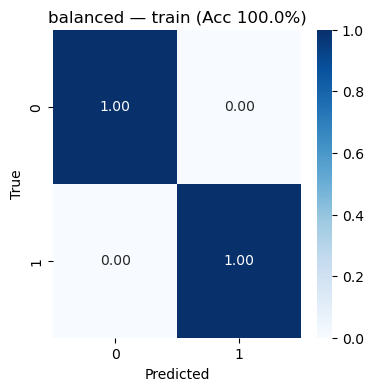

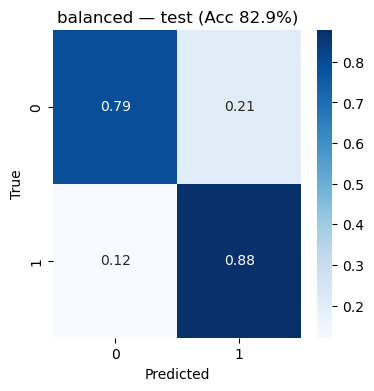

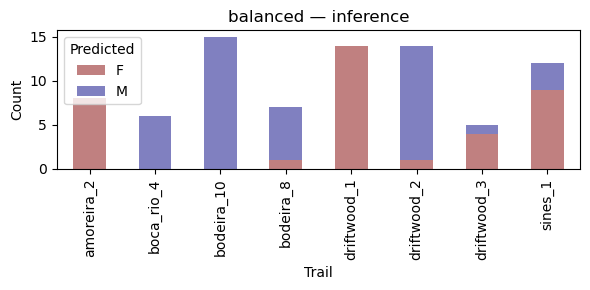

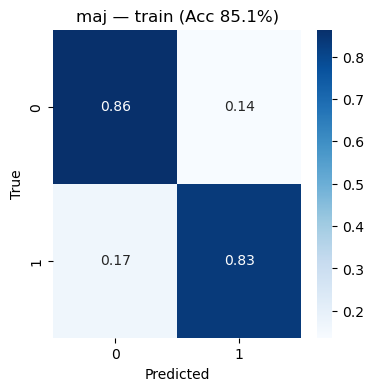

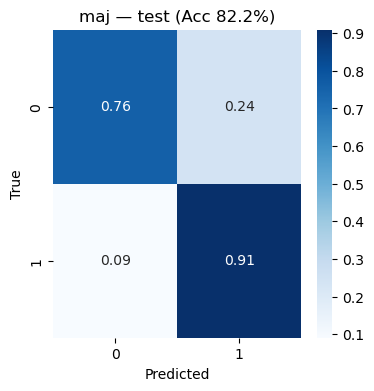

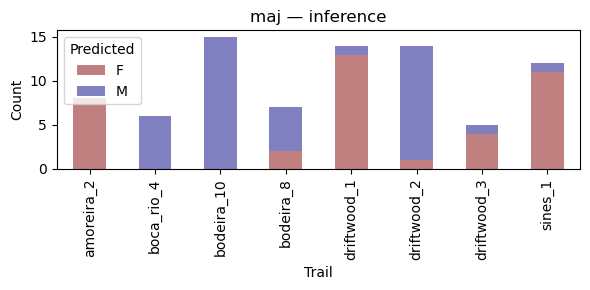

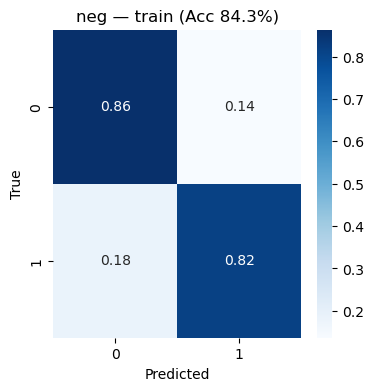

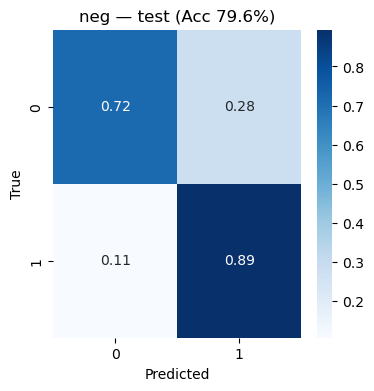

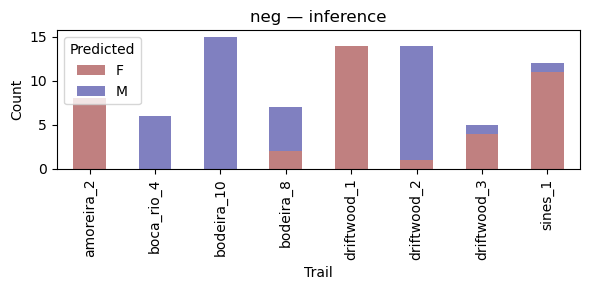

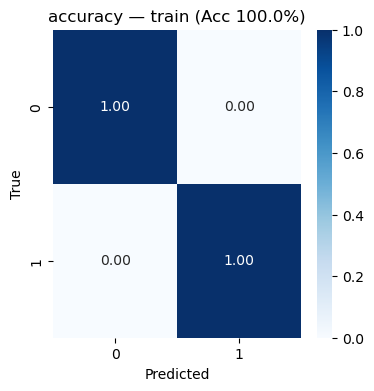

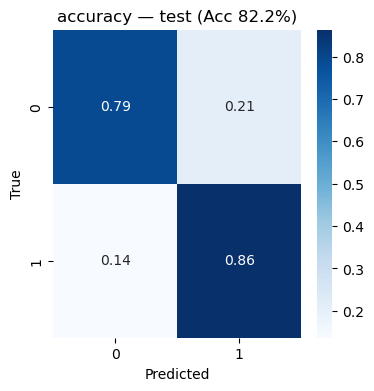

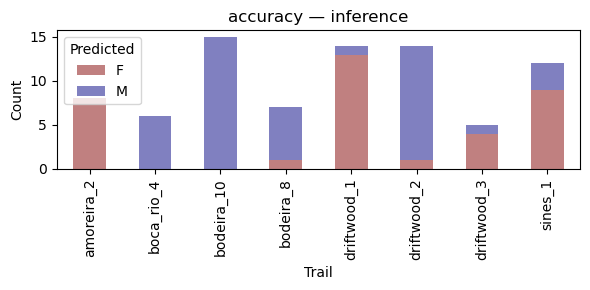

KeyError: 'pred_label_balanced_acc'

In [1]:


from FIT_python.pipeline_sex.sex_predict_and_visualisation \
    import predict_all, plot_confusion_and_inference, plot_quality
from FIT_python.config import RESULTS_DATA_DIR
import pandas as pd

# 1) Einmalig: CSV neu erzeugen (wenn nötig)
df_all = predict_all()

# 2) CSV laden und Plots zeichnen
csv = RESULTS_DATA_DIR / "eurasian_otter_random_search_standard_metrics" / "eurasian_otter_all_predictions.csv"
df   = pd.read_csv(csv)

plot_confusion_and_inference(df)
plot_quality(df)


In [ ]:
import pandas as pd
from joblib import load
from pathlib import Path
from FIT_python.config import DATA_DIR, RESULTS_DATA_DIR  # aus Eurer config

# 1) Basis-Pfade aus der config
SPLITS_DIR       = DATA_DIR        / "splits" / "eurasian_otter"
RESULTS_MODELS   = RESULTS_DATA_DIR / "eurasian_otter_random_search_standard_metrics"
OUTPUT_CSV       = RESULTS_DATA_DIR.parent / "eurasian_otter_random_search_standard_metrics" / "eurasian_otter_all_predictions.csv"
OUTPUT_CSV.parent.mkdir(parents=True, exist_ok=True)

# 2) Modelle
models = {
    "balanced_acc": RESULTS_MODELS / "best_balanced_test_acc" / "eurasian_otter.joblib",
    "maj_pct":      RESULTS_MODELS / "best_maj_test_pct"      / "eurasian_otter.joblib",
    "best_mean_test_neg_log_loss": RESULTS_MODELS / "best_mean_test_neg_log_loss"      / "eurasian_otter.joblib",
    "best_accuracy_test": RESULTS_MODELS / "best_accuracy_test"      / "eurasian_otter.joblib",

}

# 3) Splits
splits = {
    "train":     SPLITS_DIR / "train.parquet",
    "test":      SPLITS_DIR / "test.parquet",
    "inference": SPLITS_DIR / "inference.parquet",
}

# 4) Daten laden und 'set'-Spalte anfügen
dfs = {}
for split_name, path in splits.items():
    df = pd.read_parquet(path)
    df.columns = [c.replace('.', '_').replace('-', '_').replace('T', 't') for c in df.columns]
    df["__split__"] = split_name
    dfs[split_name] = df

# 5) Modelle laden & Vorhersagen anfügen
for model_name, model_fp in models.items():
    if not model_fp.is_file():
        raise FileNotFoundError(f"Modell nicht gefunden: {model_fp}")
    clf = load(model_fp)
    for split_name, df in dfs.items():
        df[f"pred_{model_name}_sex"]     = clf.predict(df)
        proba = clf.predict_proba(df)
        df[f"pred_{model_name}_proba_f"] = proba[:, 0]
        df[f"pred_{model_name}_proba_m"] = proba[:, 1]

# 6) Alles zusammenführen & speichern
all_df = pd.concat(dfs.values(), ignore_index=True)
all_df.to_csv(OUTPUT_CSV, index=False)
print(f"Alle Vorhersagen gespeichert in: {OUTPUT_CSV}")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score
from FIT_python.config import RESULTS_DATA_DIR
from pathlib import Path

# === 1) CSV laden ===
file_path = RESULTS_DATA_DIR / "eurasian_otter_random_search_standard_metrics" / "eurasian_otter_all_predictions.csv"
df = pd.read_csv(file_path)

# === 2) Spaltennamen ausgeben zum Debug (optional) ===
print("Spalten im DataFrame:", df.columns.tolist())

# === 3) Filter & Mapping ===
df = df[df.filter(like="pred_").any(axis=1)]  # Zeilen mit wenigstens einer Vorhersage
df["true_label"] = df["sex"].str.upper().map({"F":"F","M":"M"})

df = pd.read_csv(file_path)

# Labels standardisieren
df["true_label"] = df["sex"].str.upper().map({"F":"F","M":"M"})

# Confusion-Matrix-Funktion
def get_conf_matrix(y_true, y_pred, labels=["F","M"]):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    row_sums = cm.sum(axis=1, keepdims=True)
    with np.errstate(divide='ignore', invalid='ignore'):
        cm_norm = cm.astype(float)/row_sums
        cm_norm[np.isnan(cm_norm)] = 0
    annot = np.empty_like(cm).astype(object)
    for i in range(len(labels)):
        for j in range(len(labels)):
            cnt = cm[i,j]
            pct = int(round(cm_norm[i,j]*100))
            annot[i,j] = f"{cnt}\n({pct}%)"
    acc = accuracy_score(y_true, y_pred)
    return cm_norm, annot, acc

# Modelle dynamisch ermitteln
pred_sex_cols = [c for c in df.columns if c.startswith("pred_") and c.endswith("_sex")]
model_names = [c[len("pred_"):-len("_sex")] for c in pred_sex_cols]

# Splits in der Datei
splits = df["__split__"].unique()

for model_name in model_names:
    pred_col = f"pred_{model_name}_sex"
    for split_name in splits:
        df_sub = df[(df["__split__"]==split_name) & df[pred_col].isin([0,1])].copy()
        if df_sub.empty:
            continue

        df_sub["pred_label"] = df_sub[pred_col].map({0:"F",1:"M"})
        df_sub["true_label"] = df_sub["true_label"]

        if split_name != "inference":
            # Confusion Matrix für train/test
            cm, annot, acc = get_conf_matrix(df_sub["true_label"], df_sub["pred_label"])
            plt.figure(figsize=(5,5))
            im = plt.imshow(cm, vmin=0, vmax=1, cmap="Blues")
            plt.colorbar(im, fraction=0.046, pad=0.04)
            ticks = ["F","M"]
            plt.xticks(range(2), ticks)
            plt.yticks(range(2), ticks)
            plt.xlabel("Predicted")
            plt.ylabel("True")
            for i in range(2):
                for j in range(2):
                    plt.text(j, i, annot[i,j], ha="center", va="center")
            plt.tight_layout()
            plt.show()
            print(f"Dataset: {split_name}, Model: {model_name}  (Accuracy: {acc:.2%})")

        else:
            # Barplot für Inference
            pivot = df_sub.pivot_table(
                index="trail",
                columns="pred_label",
                values=pred_col,
                aggfunc="count",
                fill_value=0
            )
            ax = pivot.plot(
                kind="bar",
                stacked=True,
                figsize=(8,5),
                color={"F": "#CA201A", "M": "#2355E0"}
            )
            ax.set_xlabel("Trail")
            ax.set_ylabel("Numpber of Prints in Trail")
            plt.tight_layout()
            plt.show()
            print(f"Dataset: {split_name}, Model: {model_name}")
# Aktiviere Inline-Plots im Notebook
%matplotlib inline

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from FIT_python.config import DATA_DIR, RESULTS_DATA_DIR

# === Basis-Pfade aus config ===
MODELS_DIR = RESULTS_DATA_DIR / "eurasian_otter_random_search_standard_metrics"
CSV_PATH   = MODELS_DIR / "eurasian_otter_all_predictions.csv"

# === CSV laden ===
df = pd.read_csv(CSV_PATH)
# Korrektes Mapping ohne NaNs
df["true_label"] = df["sex"].map({"f": "F", "m": "M"})
print(f"Loaded DataFrame with {len(df)} rows; true_label unique: {df['true_label'].unique()}")

# === Helper für Heatmaps ===
def plot_quality_heatmaps(df_sub, pred_col, proba_cols):
    df = df_sub.copy()
    df["pred_label"] = df[pred_col].map({0: "F", 1: "M"})
    df["Correct"]    = df["pred_label"] == df["true_label"]
    df["Max_Prob"]   = df[proba_cols].max(axis=1)
    df["Quality"]    = df["Max_Prob"].apply(lambda p: "High" if p>0.9 else ("Moderate" if p>0.7 else "Low"))

    # MultiIndex aller Kombis
    idx = pd.MultiIndex.from_product(
        [["F","M"], [True, False]],
        names=["true_label", "Correct"]
    )
    counts = (
        df
        .groupby(["true_label", "Correct", "Quality"])
        .size()
        .unstack(fill_value=0)
        .reindex(index=idx, columns=["High","Moderate","Low"], fill_value=0)
    )
    if counts.values.sum() == 0:
        print("    → No data to plot")
        return

    normed = counts.div(counts.sum(axis=1), axis=0).fillna(0)
    def make_annot(block):
        total = block.values.sum()
        return block.applymap(
            lambda x: f"{int(x)}\n({int(round(x/total*100))}%)" if total>0 else "0\n(0%)"
        )
    annot_corr   = make_annot(counts.xs(True, level="Correct"))
    annot_incorr = make_annot(counts.xs(False, level="Correct"))

    green_cmap = LinearSegmentedColormap.from_list("green", ["white","mediumseagreen"])
    red_cmap   = LinearSegmentedColormap.from_list("red",   ["white","crimson"])
    fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True)
    sns.heatmap(
        normed.xs(True, level="Correct"),
        annot=annot_corr, fmt="",
        cmap=green_cmap, vmin=0, vmax=1,
        linewidths=0.5, linecolor="gray",
        ax=axes[0], cbar=True
    )
    axes[0].set(title="Correct Predictions", ylabel="True Label")
    sns.heatmap(
        normed.xs(False, level="Correct"),
        annot=annot_incorr, fmt="",
        cmap=red_cmap, vmin=0, vmax=1,
        linewidths=0.5, linecolor="gray",
        ax=axes[1], cbar=True
    )
    axes[1].set(title="Incorrect Predictions")
    for ax in axes:
        ax.set_xlabel("Prediction Quality")
        ax.set_xticklabels(["High","Moderate","Low"], rotation=0)
        ax.set_yticklabels(["F","M"], rotation=0)
    plt.tight_layout()
    plt.show()

# === Für jeden Split und jedes Modell plotten ===
pred_sex_cols = [c for c in df.columns if c.startswith("pred_") and c.endswith("_sex")]
for split in ["train", "test"]:
    for pred_col in pred_sex_cols:
        model = pred_col[len("pred_"):-len("_sex")]
        proba_cols = [f"pred_{model}_proba_f", f"pred_{model}_proba_m"]
        df_sub = df[df["__split__"] == split].copy()
        df_sub = df_sub[df_sub[pred_col].isin([0, 1])]
        print(f"Dataset: {split}, Model: {model}, Rows: {len(df_sub)}")
        if df_sub.empty:
            continue
        plot_quality_heatmaps(df_sub, pred_col, proba_cols)

# Aktiviere Inline-Plots im Notebook
%matplotlib inline

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from FIT_python.config import RESULTS_DATA_DIR

# === Basis-Pfade ===
MODELS_DIR = RESULTS_DATA_DIR / "eurasian_otter_random_search_standard_metrics"
CSV_PATH   = MODELS_DIR / "eurasian_otter_all_predictions.csv"

# === CSV laden ===
df = pd.read_csv(CSV_PATH)
df["true_label"] = df["sex"].map({"f":"F","m":"M"})

# Klassifizierungsqualität
def classify_majority_accuracy(group):
    acc = group["Correct"].mean()
    if   acc >= 0.9: return "High"
    elif acc >= 0.7: return "Moderate"
    elif acc >= 0.5: return "Low"
    else:            return "Misclassified"

# Modelle ermitteln
pred_sex_cols = [c for c in df.columns if c.startswith("pred_") and c.endswith("_sex")]
model_names   = [c[len("pred_"):-len("_sex")] for c in pred_sex_cols]

for model in model_names:
    print(f"\n==== Model: {model} ====")
    pred_col   = f"pred_{model}_sex"
    proba_cols = [f"pred_{model}_proba_f", f"pred_{model}_proba_m"]

    # pred_label & Correct
    df_mod = df.copy()
    df_mod["pred_label"] = df_mod[pred_col].map({0:"F",1:"M"})
    df_mod["Correct"]    = df_mod["pred_label"] == df_mod["true_label"]

    # Erstelle Pivot für Trail- und Animal-Level
    pivots = []
    for level, group_cols in zip(
        ["trail", "individual_id"],
        [["trail","true_label"], ["individual_id","true_label"]]
    ):
        quality = (
            df_mod
            .groupby(group_cols, group_keys=False)
            .apply(classify_majority_accuracy)
            .reset_index(name="Class")
        )
        piv = (
            quality
            .pivot_table(index="true_label", columns="Class", values=level,
                         aggfunc="count", fill_value=0)
            .reindex(columns=["High","Moderate","Low","Misclassified"], fill_value=0)
        )
        pivots.append(piv)

    # Plot
    cmap = LinearSegmentedColormap.from_list("green", ["white","mediumseagreen"])
    fig, axes = plt.subplots(1, 2, figsize=(12,5), sharey=True)
    class_labels = ["High","Moderate","Low","Misclassified"]
    y_labels     = ["F","M"]

    for ax, piv, tag, label_info in zip(
        axes, pivots, ["a)", "b)"],
        ["(trail-level)", "(animal-level)"]
    ):
        # Prozentwerte
        totals      = piv.sum(axis=1)
        props       = piv.div(totals, axis=0).fillna(0)
        counts      = piv.astype(int)
        total_sum   = counts.values.sum()

        # Annotation per Zelle
        annot = pd.DataFrame("", index=counts.index, columns=counts.columns)
        for i in counts.index:
            for j in counts.columns:
                v = counts.at[i, j]
                if v:
                    annot.at[i, j] = f"{v}\n({v/total_sum:.0%})"

        sns.heatmap(
            props, annot=annot, fmt="",
            cmap=cmap, vmin=0, vmax=1,
            linewidths=0.5, linecolor="gray",
            ax=ax, cbar=True
        )
        # Nur "a)" bzw "b)" als Titel
        ax.set_title(tag, loc="left", fontsize=14, fontweight="bold")
        # Info als Kommentar an die Achse
        ax.text(1.02, 0.5, label_info, transform=ax.transAxes,
                rotation=90, va="center", fontsize=10, color="gray")
        ax.set_ylabel("True Sex")
        ax.set_yticks(np.arange(len(y_labels)) + 0.5)
        ax.set_yticklabels(y_labels, rotation=0)
        ax.set_xticks(np.arange(len(class_labels)) + 0.5)
        ax.set_xticklabels(class_labels, rotation=45, ha="right")
        ax.set_xlabel("Classification Quality")

        # Drucke die reinen Counts drunter
        print(f"{tag} counts {label_info}:\n{counts}\n")

    plt.tight_layout()
    plt.show()


Alle Vorhersagen gespeichert in: C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\results\eurasian_otter_random_search_standard_metrics\eurasian_otter_all_predictions.csv
